First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [1]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions


In [2]:
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

from argparse import Namespace
import time
import sys
import pprint
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(".")
sys.path.append("..")

# from datasets import augmentations
from utils.common import tensor2im, log_input_image
# from models.psp import pSp

from notebooks.def_funcs import load_sparsity_model, load_pretained_pSp_net, evaluate_model, transform_images_to_batch, load_folder_images, \
    show_latent_map, visulize_singleImg_paired2, visulize_singleImg_paired3, visulize_singleImg_paired4, visulize_singleImg_paired5
# %load_ext autoreload
# %autoreload 2

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive


In [3]:
EXPERIMENT_PARMS = {
        # "model_orn_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pretrained_models/e4e_models/e4e_ffhq_encode.pt",
        "cs_model_path": "./results/csmlp_ffhq_glasses/mlp3D/nodim/checkpoints/iteration_200000.pt",
        "pSp_model_path": "../pretrained_models/pSp_models/psp_ffhq_encode.pt",
        # "model1_path": "./results/csmlp_sparsity/mlp3D/nodim/checkpoints/iteration_100000.pt",
        # "model2_path": "./results/csmlp_sparsity/mlp3D/nodim/checkpoints/iteration_100000.pt",
        "images_bg_path" : "../eval_images/test_bg_imgs/", 
        "images_t_path" : "../eval_images/test_t_imgs/", 
        "model_output_size" : 1024,
        "transform": transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])]) 
}

In [4]:
cs_model_path = EXPERIMENT_PARMS["cs_model_path"]
pSp_model_path = EXPERIMENT_PARMS["pSp_model_path"]
image_bg_paths = EXPERIMENT_PARMS["images_bg_path"]
image_t_paths = EXPERIMENT_PARMS["images_t_path"]

transform = EXPERIMENT_PARMS['transform']
device = 'cuda'


In [5]:
%matplotlib inline
images_bg= load_folder_images(image_bg_paths)
images_t= load_folder_images(image_t_paths)

input_images_bg = transform_images_to_batch(images_bg, transform).to(device).float()
input_images_t = transform_images_to_batch(images_t, transform).to(device).float()


### Load pretrained pSp model

In [6]:
pSp_net, opts = load_pretained_pSp_net(cs_model_path, map_location = 'cpu', output_size = 1024, pSp_ckpt_path = pSp_model_path)

Loading pSp from checkpoint: ../pretrained_models/pSp_models/psp_ffhq_encode.pt


In [ ]:


with torch.no_grad():

    _, w_bg_pSp = pSp_net.forward(input_images_bg, return_latents=True) 
    codes_bg_pSp = pSp_net.forward(input_images_bg, encode_only=True) 

    _, w_t_pSp = pSp_net.forward(input_images_t, return_latents=True)  
    codes_t_pSp = pSp_net.forward(input_images_t, encode_only=True) 

    rec_pSp_latent_bg = pSp_net.forward(w_bg_pSp, input_code=True, randomize_noise=False, recon_modle=True)
    rec_pSp_code_bg = pSp_net.forward(codes_bg_pSp, input_code=True, randomize_noise=False, recon_modle=True)

    rec_pSp_latent_t = pSp_net.forward(w_t_pSp, input_code=True, randomize_noise=False, recon_modle=True)
    rec_pSp_code_t = pSp_net.forward(codes_t_pSp, input_code=True, randomize_noise=False, recon_modle=True)

    # rec_x_bg_pSp, orn_w_bg_pSp, w_bg_pSp = pSp_net.forward(input_images_bg, return_latents=True, return_codes=True)  

    # rec_x_bg_pSp1 = pSp_net.forward(shift_with_avg(orn_w_bg_pSp), input_code=True, randomize_noise=True, recon_modle=True)
    # rec_x_bg_pSp2 = pSp_net.forward(w_bg_pSp, input_code=True, randomize_noise=True, recon_modle=True)

    # latent_bg_c1, latent_bg_s = csmlp_net(orn_w_bg_pSp, zero_out_silent=opts.zero_out_silent_t)
    # latent_bg_c2, latent_bg_s = csmlp_net(w_bg_pSp, zero_out_silent=opts.zero_out_silent_t)

    # rec_x_bg1 = pSp_net.forward(latent_bg_c1, input_code=True, randomize_noise=True, recon_modle=True)
    # rec_x_bg2 = pSp_net.forward(latent_bg_c2, input_code=True, randomize_noise=True, recon_modle=True)

frobenius_distance1 = torch.norm(w_bg_pSp - codes_bg_pSp, p='fro')  # Frobenius norm
frobenius_distance2 = torch.norm(codes_t_pSp - w_t_pSp, p='fro')  # Frobenius norm
print(f"Frobenius distance: {frobenius_distance1}")
print(f"Frobenius distance: {frobenius_distance2}")
# output_images_1, output_latents_1 = evaluate_model(csmlp_net1, pSp_net1, input_images_bg, input_images_t, opts1)


Frobenius distance: 0.0
Frobenius distance: 0.0


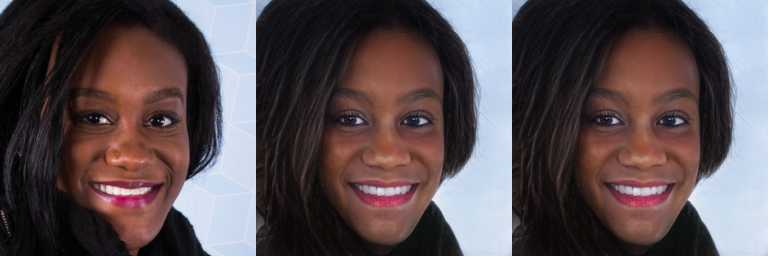

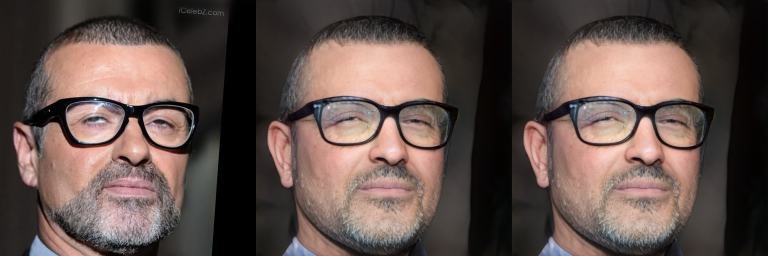

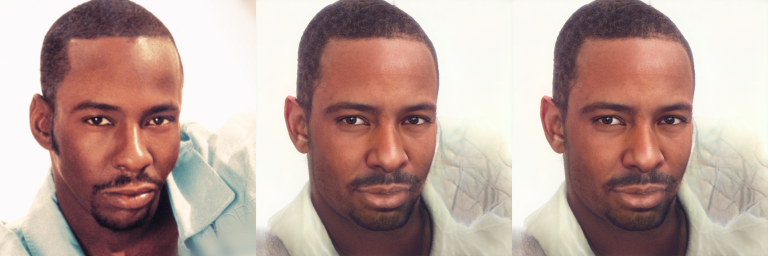

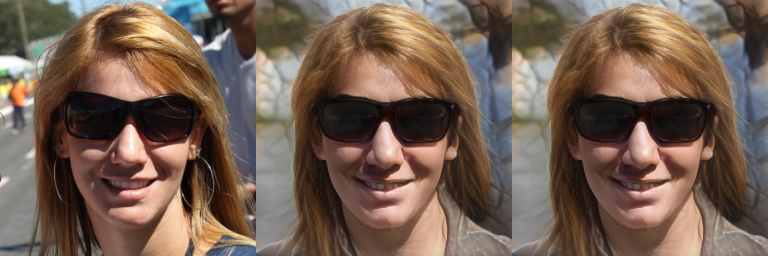

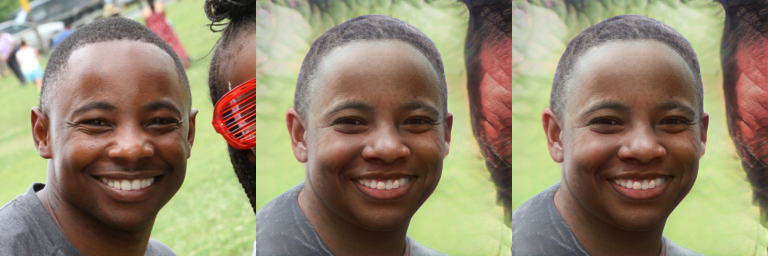

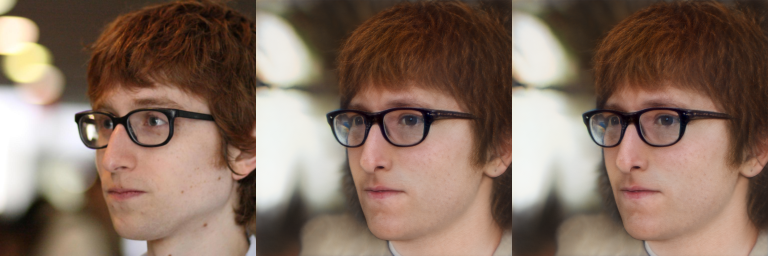

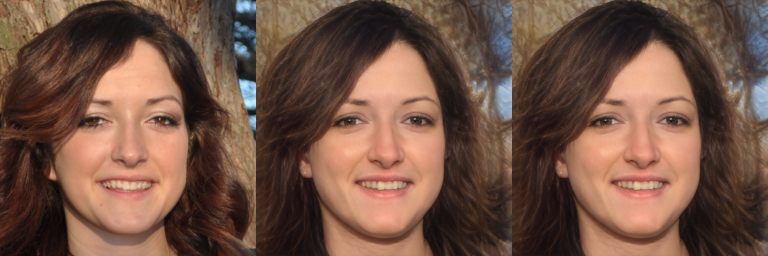

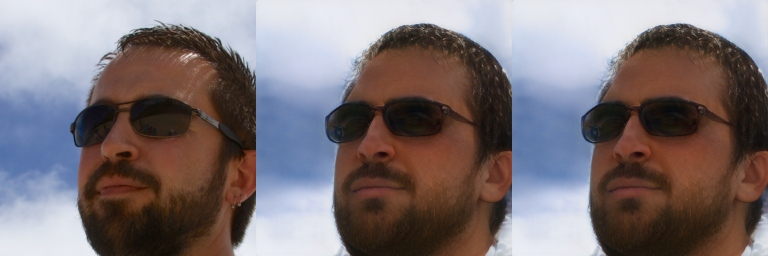

In [8]:
# # # visulize_images_batch(recon_t, axis_dim=1) 
n_images = rec_pSp_latent_bg.shape[0]

for i in range (n_images):
    visulize_singleImg_paired3(input_images_bg[i,:,:,:], rec_pSp_latent_bg[i,:,:,:], rec_pSp_code_bg[i,:,:,:])
    visulize_singleImg_paired3(input_images_t[i,:,:,:], rec_pSp_latent_t[i,:,:,:], rec_pSp_code_t[i,:,:,:])